In [1]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.convolution import convolve
from astropy.modeling.models import Sersic2D
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u
from astropy.constants import c
from reproject import reproject_interp
from scipy.optimize import minimize, least_squares
from scipy.signal import fftconvolve, convolve2d
import dynesty
import dynesty.pool as dypool
from dynesty import plotting as dyplot
import dynesty.utils as dyutil
import pickle
import corner
from cmcrameri import cm
from multiprocessing import Pool
import importlib
from tqdm import tqdm
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
%matplotlib inline
# seed the random number generator
rstate = np.random.default_rng(111)

from glint.beam import cleanbeam_from_header
import glint.lensing as ls
from glint.context import ImageContext, UVContext, build_finufft_plans, build_uv_layout
from glint.forward import forward_model_3D_image, forward_model_3D_vis
from glint.inference import run_emcee
from glint.plotstyle import set_my_plot_style
from glint.interferometry import primary_beam, vis_to_image_finufft_type3
from params_kinematics import param_names, param_table

In [2]:
set_my_plot_style()

In [3]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

## Data

Beam size: 0.21, 0.12


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


hst peak: 8.0, 17.0 pix, corresponding to 0.160, 0.340 arcsec from the center
hst centroid: 4.7, 3.5 pix, corresponding to 0.093, 0.070 arcsec from the center
hst gaussian fit: 10.8, 14.5 pix, corresponding to 0.217, 0.290 arcsec from the center
Number of pixels in the mask: 30164


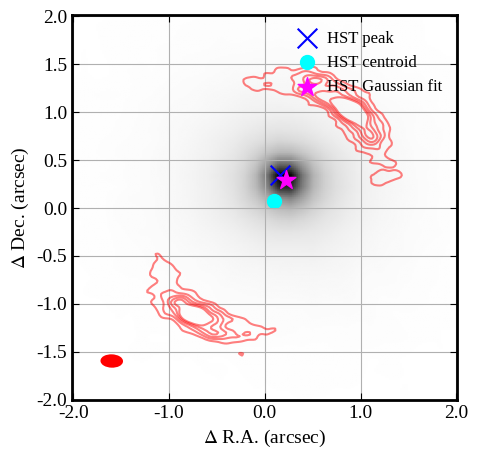

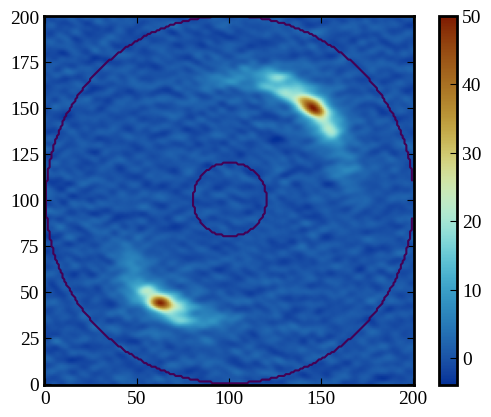

In [4]:
#########################################
# [C II] data/noise cube and PSF
#########################################
data_dir = Path("./data").resolve()
data_dir.exists()

obsfits   = str(data_dir / "B6_concat_CII_dv50km_rob-0.5_clean.image.pbcor.cutout.-250+300km.fits")
noisefits = str(data_dir / "B6_concat_CII_dv50km_rob-0.5_clean.noise.pbcor.cutout.-250+300km.fits")

obsdata, obsheader = fits.getdata(obsfits, header=True)
noisedata = fits.getdata(noisefits)
noisedata_inv = 1/noisedata
BMAJ, BMIN, BPA, CDELT = obsheader['BMAJ'], obsheader['BMIN'], obsheader['BPA'], obsheader['CDELT2']
print(f"Beam size: {BMAJ*3600:.2f}, {BMIN*3600:.2f}")
beam = cleanbeam_from_header(35, obsheader)


#########################################
# continuum data/noise
#########################################
contfits   = str(data_dir / "B6_concat_cont_rob-0.5_clean.image.pbcor.cutout.fits")
contnoisefits = str(data_dir / "B6_concat_cont_rob-0.5_clean.noise.pbcor.cutout.fits")

contdata, contheader = fits.getdata(contfits, header=True)
contnoisedata = fits.getdata(contnoisefits)


#########################################
# HST data
#########################################
hst_fits = str(data_dir / "hst_skycell-p1356x14y05_wfc3_ir_f125w_coarse-all_drz.fits")
hst_data, hst_header = fits.getdata(hst_fits, header=True)
hst_wcs = WCS(hst_header)

# reproject to ALMA
hst_on_alma, footprint = reproject_interp((hst_data, hst_wcs), WCS(contheader, naxis=2), shape_out=contdata.shape)

#########################################
# ALMA and HST overlay
#########################################
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(hst_on_alma, origin='lower', cmap='gray_r')
ax.contour(contdata/contnoisedata, levels=[4,8,12,16,20], colors='red', alpha=0.5)

# 画像の中心
ny, nx = contdata.shape
x0 = (nx - 1) / 2
y0 = (ny - 1) / 2
pixscale_as = abs(obsheader['CDELT2'] * 3600) # arcsec/pix
def format_func_x(x_pix, _):
    return f"{(x_pix - x0) * pixscale_as:.1f}"
def format_func_y(y_pix, _):
    return f"{(y_pix - y0) * pixscale_as:.1f}"
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(format_func_x))
ax.yaxis.set_major_formatter(FuncFormatter(format_func_y))

# psfサイズをimage planeの左下に楕円として表示
xy_beam = (0.10*nx, 0.10*ny)
ellipse = Ellipse(xy=xy_beam, width=BMAJ/CDELT, height=BMIN/CDELT, angle=BPA+90, edgecolor='red', facecolor='red', lw=1.5)
ax.add_patch(ellipse)
ax.grid()

# HST peak
hst_peak = np.unravel_index(np.nanargmax(hst_on_alma), hst_on_alma.shape)
ax.scatter(hst_peak[1], hst_peak[0], marker='x', color='blue', s=200, label='HST peak')

# HST centroid
from photutils.centroids import centroid_com
y_com, x_com = centroid_com(hst_on_alma)
ax.scatter(x_com, y_com, marker='o', color='cyan', s=100, label='HST centroid')

# HST gaussian fit
def gauss2d(p, x, y):
    A, x0, y0, sx, sy, rho, c = p
    # 相関rho入り楕円ガウス：必要なければ rho=0 に固定
    X = (x - x0); Y = (y - y0)
    z = (X/sx)**2 + (Y/sy)**2 - 2*rho*X*Y/(sx*sy)
    return A*np.exp(-0.5/(1-rho**2) * z) + c
ny, nx = hst_on_alma.shape
yy, xx = np.indices((ny, nx))
p0 = [hst_on_alma.max(), x_com, y_com, 3.0, 3.0, 0.0, 0.0]
use = np.isfinite(hst_on_alma)
def resid(p): return (gauss2d(p, xx[use], yy[use]) - hst_on_alma[use])
res = least_squares(resid, p0, bounds=([0,0,0,0.5,0.5,-0.5,-np.inf],
                                       [np.inf,nx,ny,50,50,0.5,np.inf]))
A,x0_g,y0_g,sx,sy,rho,c = res.x
ax.scatter(x0_g, y0_g, marker='*', color='magenta', s=200, label='HST Gaussian fit')

ax.set_xlabel(r"$\Delta$ R.A. (arcsec)", fontsize=14)
ax.set_ylabel(r"$\Delta$ Dec. (arcsec)", fontsize=14)
ax.legend(fontsize=12)
print(f"hst peak: {hst_peak[1]-x0:.1f}, {hst_peak[0]-y0:.1f} pix, corresponding to {((hst_peak[1]-x0)*pixscale_as):.3f}, {((hst_peak[0]-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst centroid: {x_com-x0:.1f}, {y_com-y0:.1f} pix, corresponding to {((x_com-x0)*pixscale_as):.3f}, {((y_com-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst gaussian fit: {x0_g-x0:.1f}, {y0_g-y0:.1f} pix, corresponding to {((x0_g-x0)*pixscale_as):.3f}, {((y0_g-y0)*pixscale_as):.3f} arcsec from the center")

#########################################
# lens center in image plane
#########################################
x0_l = (x0_g-x0)*pixscale_as
y0_l = (y0_g-y0)*pixscale_as


#########################################
# mask definition
#########################################
maskdata = np.zeros(contdata.shape).astype(bool)

# RMS基準にマスクを定義する場合
# thresh = 2
# maskdata[obsdata*noisedata_inv > thresh] = True

# 固定マスクを使う場合
# 円環マスク
r_inner = 0.4 # arcsec
r_outer = 2.0 # arcsec
y, x = np.indices(contdata.shape)
x_center = contdata.shape[1] / 2
y_center = contdata.shape[0] / 2
r = np.sqrt((x - x_center)**2 + (y - y_center)**2) * np.abs(CDELT) * 3600
maskdata[(r >= r_inner) & (r <= r_outer)] = True


Npix = np.nansum(maskdata)
print(f"Number of pixels in the mask: {Npix}")

# mask
# obsdata[maskdata==0] = np.nan
# noisedata_inv[maskdata==0] = np.nan

#########################################
# maskの確認
#########################################
fig, ax = plt.subplots()
im = ax.imshow(contdata/contnoisedata, origin="lower", cmap=cm.roma_r)
ax.contour(maskdata)
fig.colorbar(im, ax=ax)

In [5]:
#########################################
# 座標を張る
#########################################
# source plane grid
ny_src, nx_src = 200, 200
pixsize_src = 0.005 # arcsec
x0_src, y0_src = 0.0, 0.0
xx_src, yy_src = ls.make_grid_arcsec(nx=nx_src, ny=ny_src, pixscale_arcsec=pixsize_src, x0_arcsec=x0_src, y0_arcsec=y0_src)

# image plane grid
_, ny_img, nx_img = obsdata.shape
pixsize_img = (np.abs(obsheader['CDELT2'])*3600).round(5)
print(f"Number of pixels in image plane: {nx_img} x {ny_img}")
print(f"Pixel scale in image plane: {pixsize_img} arcsec/pixel")
x0_img, y0_img = 0.0, 0.0
xx_img, yy_img = ls.make_grid_arcsec(nx=nx_img, ny=ny_img, pixscale_arcsec=pixsize_img, x0_arcsec=x0_img, y0_arcsec=y0_img)

radius = np.arange(0, 0.8+1e-6, 0.01) # 0含める

spec_res_sgm_kms = 50 / (2 * np.sqrt(2 * np.log(2)))  # 50 km/s channel width -> sigma
print(f"Spectral resolution (sigma): {spec_res_sgm_kms:.1f} km/s")

Number of pixels in image plane: 201 x 201
Pixel scale in image plane: 0.02 arcsec/pixel
Spectral resolution (sigma): 21.2 km/s


In [6]:
from astropy.constants import c
# 周波数方向の情報

# model作成時は速度で指定
vchan_kms = np.arange(-300, 351, 50) # 後でmock cleantするときに箸が切れないように端に一つづつおおめにとる
nchan = len(vchan_kms)
print(f"Number of channels: {nchan}")

# [CII]158を想定
REST_FREQ_CII = 1900.5369 * u.GHz
z = 6.024
OBS_FREQ_CII = REST_FREQ_CII / (1 + z)

# Transform velocity channels to frequency channels
# V/c = -dnu/f --> dnu = - (V/c) * f --> nu = f + dnu = f * (1 - V/c)
fchan_GHz = (OBS_FREQ_CII * (1 - vchan_kms / c.to(u.km / u.s).value)).to(u.GHz).value
print(fchan_GHz)

f0 = fchan_GHz[0]
df = np.mean(np.diff(fchan_GHz))
print(f"f0: {f0} GHz, df: {df} GHz, RESTFRQ: {OBS_FREQ_CII.to(u.GHz).value} GHz")

Number of channels: 14
[270.84834177 270.80321429 270.75808681 270.71295933 270.66783184
 270.62270436 270.57757688 270.5324494  270.48732191 270.44219443
 270.39706695 270.35193947 270.30681199 270.2616845 ]
f0: 270.84834177310904 GHz, df: -0.045127482306322866 GHz, RESTFRQ: 270.5775768792711 GHz


## Intrinsic cube model

In [7]:
# inclination from mom-0 fit

savename = f"./mcmc_chain_CII_mom0_image.npz"
npzfile = np.load(savename, allow_pickle=True)

chain = npzfile["chain"]              # shape: (nsteps, nwalkers, ndim)
logprob = npzfile["logprob"]          # shape: (nsteps, nwalkers)
param_names_mom0 = list(npzfile["param_names"])

# 最も logprob が大きい点を best-fit とする
idx = np.unravel_index(np.argmax(logprob), logprob.shape)
best_theta = chain[idx[0], idx[1], :]

for name, best in zip(param_names_mom0, best_theta):
    print(f"{name:12s}  best={best:10.4f}")

x_s_from_mom0_fit = best_theta[0]
y_s_from_mom0_fit = best_theta[1]
ellip = best_theta[3]
axis_ratio = 1 - ellip
print(f"Best-fit axis ratio: {axis_ratio:.3f}")
inc_deg_from_mom0_fit = np.degrees(np.arccos(axis_ratio))
print(f"Best-fit inclination: {inc_deg_from_mom0_fit:.2f} deg")

x_s           best=    0.0348
y_s           best=    0.0291
F_0           best=    9.4547
ellip         best=    0.1517
pa_deg        best=  100.4099
r_eff         best=    0.2009
n             best=    0.5000
b             best=    1.2845
q_l           best=    0.9558
pa_l          best=    2.3784
log_gamma     best=   -1.2749
pa_gamma      best=    1.0912
Best-fit axis ratio: 0.848
Best-fit inclination: 31.97 deg


In [8]:
# beamを2Dから3Dに拡張(channel 方向に繰り返すだけ)
beam_3D = np.repeat(beam[np.newaxis, :, :], nchan, axis=0)

In [9]:
img_ctx = ImageContext(
    xx_img = xx_img,
    yy_img = yy_img,
    xx_src = xx_src,
    yy_src = yy_src,
    pixsize_img = pixsize_img,
    pixsize_src = pixsize_src,
    x0_src = x0_src,
    y0_src = y0_src,
    x0_l = x0_l,
    y0_l = y0_l,
    vchan_kms = vchan_kms,
    spec_res_sgm_kms = spec_res_sgm_kms,
    radius_arcsec = radius,
    beam = beam_3D,
    x_s = x_s_from_mom0_fit,
    y_s = y_s_from_mom0_fit,
    inc_deg = inc_deg_from_mom0_fit
)

__下のセルは1_kinematics_image_CCD.ipynbからコピペ__

In [10]:
mock_x_s, mock_y_s = 0.034, 0.029
mock_F_0 = 0.5
mock_inc_deg = 30.0
mock_pa_deg = 45.0
mock_r_scale = 0.1 # arcsec
mock_v_c = 350.0 # km/s
mock_r_turn = 0.1 # arcsec
mock_beta_curve = 0.8
mock_gamma_curve = 2.5
mock_sigma_0 = 100.0 # km/s
mock_r_sigma = 0.8 # arcsec
mock_vsys_kms = 20.0 # km/s
mock_x_l, mock_y_l = x0_l, y0_l
mock_b = 1.2 # arcsec
mock_q_l = 0.95
mock_pa_l = np.pi/2 # rad
mock_log_gamma = -2
mock_pa_gamma = np.pi/4 # rad

mock_params = [
    # mock_x_s, mock_y_s, mock_F_0, mock_inc_deg, mock_pa_deg, mock_r_scale,
    mock_F_0, mock_pa_deg, mock_r_scale,
    # mock_v_c, mock_r_turn, mock_beta_curve, mock_gamma_curve, mock_sigma_0, mock_r_sigma, mock_vsys_kms,
    # mock_v_c, mock_r_turn, mock_beta_curve, mock_gamma_curve, mock_sigma_0, mock_r_sigma,
    mock_v_c, mock_r_turn, mock_beta_curve, mock_gamma_curve, mock_sigma_0, mock_r_sigma, mock_vsys_kms,
    mock_b, mock_q_l, mock_pa_l, mock_log_gamma, mock_pa_gamma
    # mock_x_l, mock_y_l, mock_b, mock_q_l, mock_pa_l, mock_log_gamma, mock_pa_gamma
]


# mock_source, mock_lensed_cube, mock_lensed_cube_conv = forward_model_3D_image(mock_params, img_ctx)

# # mock rms
# rms = np.max(mock_lensed_cube_conv) / 10.0
# mock_lensed_cube_conv += rstate.normal(loc=0.0, scale=rms, size=mock_lensed_cube_conv.shape)


# # minimum header
# header = WCS(obsheader).to_header()
# header["BUNIT"] = "Jy/pix"

# # frequency axis info
# header['CRPIX3'] = 1
# header['CRVAL3'] = f0 * 1e9  # Hz
# header['CDELT3'] = df * 1e9  # Hz
# header['CUNIT3'] = 'Hz'
# header['RESTFRQ'] = OBS_FREQ_CII.to(u.Hz).value

# save mock data
# fits.writeto("mock_source_cube.fits", mock_source, header=header, overwrite=True)
# fits.writeto("mock_lensed_cube.fits", mock_lensed_cube, header=header, overwrite=True)

In [11]:
x0 = param_table[:,0]
lb = param_table[:,1]
ub = param_table[:,2]
ndim = len(lb)

## uv data load

In [12]:
# load uv data
uvpack = np.load("./sim_imaging/sim_imaging.processed_uv_CII.npz", allow_pickle=True)
flag = uvpack['flag'].astype(bool)

u_m, v_m, w_m = uvpack['uvw']
u, v, w = uvpack['uvw_lam']
v_kms = uvpack['v_kms']
freqs = uvpack['freqs']
nchan = len(v_kms)
spec_res_sgm_kms = abs(np.median(v_kms[1:] - v_kms[:-1]) / 2.355)  # channel width -> sigma

vis = uvpack['data']
vis_sigma = uvpack['sigma']
vis_sigma_inv = 1/vis_sigma
pb_fwhm_as = uvpack['pb_fwhm']
phase_center = uvpack['phase_dir']  # [deg]
print(f"Shape of u,v,w: {u.shape}")
print(f"Nchan: {nchan}")
print(f"Velocity channels (km/s): {v_kms}")
print(f"Shape of vis: {vis.shape}")
print(f"Shape of vis_sigma: {vis_sigma.shape}")
print(f"Shape of flag: {flag.shape}")
print()

# phase center check
header_phase = obsheader['CRVAL1'], obsheader['CRVAL2']
print(f"phase center in MS (deg): {phase_center}")
print(f"phase center in FITS (deg): {header_phase}")
print(f"Difference (deg): {phase_center[0] - header_phase[0]}, {phase_center[1] - header_phase[1]}")
header_centerpixel = (obsheader['CRPIX1']-1, obsheader['CRPIX2']-1) # headerのpixel座標は1始まりなので-1する
print(f"phase center in FITS (pixel): {header_centerpixel}")
print(f"image center pixel: {(nx_img-1)/2, (ny_img-1)/2}")
print(f"Difference (pixel): {header_centerpixel[0] - (nx_img-1)/2}, {header_centerpixel[1] - (ny_img-1)/2}")

#######################
# theta = 0.6 lambda / Lmin
# theta = 4 arcsec以上に対応するuv dataは削除する
#######################
from astropy import units
from astropy import constants as const
lambda_cii = const.c.value / freqs
Lmin = 0.6 * lambda_cii / (4 * units.arcsec.to(units.rad))  # uv data with baseline length < Lmin are kept
uv_radius = np.sqrt(u_m**2 + v_m**2)
Lmin, uv_radius

mask_uvdist = (uv_radius < Lmin[:, None])
print(mask_uvdist.shape, mask_uvdist.sum())
# flagにmask_uvdist追加
print(np.sum(flag))
flag = flag | mask_uvdist
print(np.sum(flag))
#######################

# use only unflagged data
u, v, w = np.where(flag, np.nan, u), np.where(flag, np.nan, v), np.where(flag, np.nan, w)
vis = np.where(flag, np.nan, vis)
vis_sigma = np.where(flag, np.nan, vis_sigma)
vis_sigma_inv = np.where(flag, np.nan, vis_sigma_inv)
print()
print(f"Number of visibilities: {u.size}, {np.sum(flag==0)} unflagged, {np.sum(flag==1)} flagged")
print(f"Fraction of unflagged data: {np.sum(flag==0)/flag.size:.3f}")

# primary beam
pb = primary_beam(xx_img, yy_img, pb_fwhm_as=pb_fwhm_as)

Shape of u,v,w: (14, 903)
Nchan: 14
Velocity channels (km/s): [-300 -250 -200 -150 -100  -50    0   50  100  150  200  250  300  350]
Shape of vis: (14, 903)
Shape of vis_sigma: (14, 903)
Shape of flag: (14, 903)

phase center in MS (deg): [135.19097083   0.68977778]
phase center in FITS (deg): (135.1909708333, 0.6897777777778)
Difference (deg): 3.33386651618639e-11, -2.220446049250313e-14
phase center in FITS (pixel): (100.0, 100.0)
image center pixel: (100.0, 100.0)
Difference (pixel): 0.0, 0.0
(14, 903) 28
0
28

Number of visibilities: 12642, 12614 unflagged, 28 flagged
Fraction of unflagged data: 0.998


In [13]:
k_list, slices, Ntot = build_uv_layout(u, v, flag)
print("Total unflagged vis =", Ntot)

Total unflagged vis = 12614


In [14]:
ARCSEC2RAD = np.deg2rad(1/3600)
l_rad = (xx_img * ARCSEC2RAD).ravel().astype(np.float32, order="C")
m_rad = (yy_img * ARCSEC2RAD).ravel().astype(np.float32, order="C")

In [15]:
plans = build_finufft_plans(
    k_list,
    l_rad,
    m_rad,
    eps=1e-6
)

In [16]:
uv_ctx = UVContext(
    pb=pb,
    plans=plans,
    slices=slices,
    nchan=nchan,
    Ntot=Ntot,
    flag=flag
)

In [17]:
x0 = param_table[:,0]
lb = param_table[:,1]
ub = param_table[:,2]
ndim = len(lb)

In [18]:
Vobs_all = np.concatenate([vis[i, ~flag[i]] for i in range(nchan)])
Vsiginv_all = np.concatenate([vis_sigma_inv[i, ~flag[i]] for i in range(nchan)])

In [19]:
model_vis = forward_model_3D_vis(x0, img_ctx, uv_ctx)

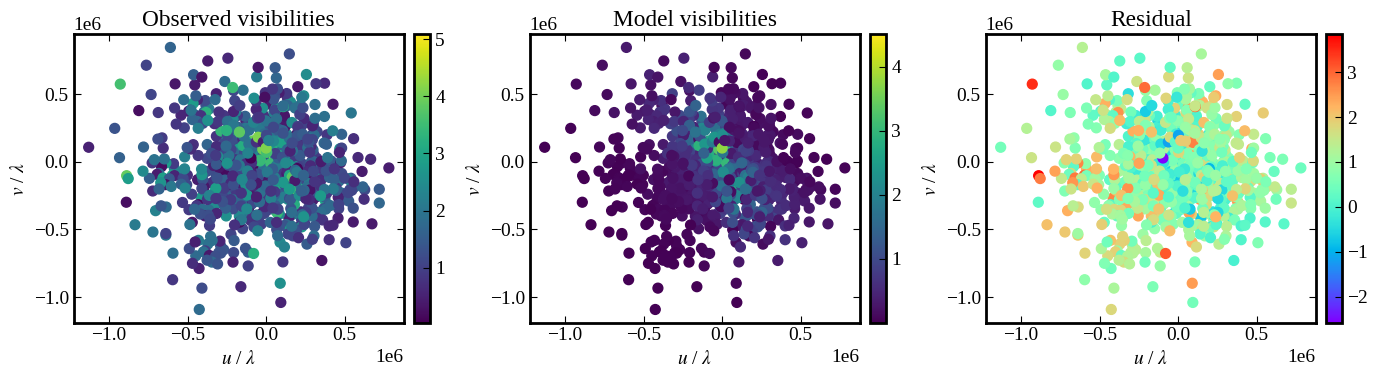

In [20]:
ii = 12
m = ~flag[ii]

model_vis_all = forward_model_3D_vis(mock_params, img_ctx, uv_ctx)
model_vis_i = model_vis_all[slices[ii]]

obs_amp = np.abs(vis[ii, m]) / vis_sigma[ii, m]
mod_amp = np.abs(model_vis_i) / vis_sigma[ii, m]
res_amp = obs_amp - mod_amp

f, ax = plt.subplots(1, 3, figsize=(14, 4))
im0 = ax[0].scatter(u[ii, m], v[ii, m], c=obs_amp, s=50)
im1 = ax[1].scatter(u[ii, m], v[ii, m], c=mod_amp, s=50)
im2 = ax[2].scatter(u[ii, m], v[ii, m], c=res_amp, s=50, cmap="rainbow")

im = [im0, im1, im2]
titles = ["Observed visibilities", "Model visibilities", "Residual"]
for j in range(3):
    ax[j].set_title(titles[j])
    divider = make_axes_locatable(ax[j])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    f.colorbar(im[j], cax=cax, orientation='vertical')
    ax[j].set_xlabel(r"$u$ / $\lambda$")
    ax[j].set_ylabel(r"$v$ / $\lambda$")

plt.tight_layout()
plt.show()

## Fitting

In [21]:
# from glint.inference import run_least_squares

# dof = np.sum(maskdata) * obsdata.shape[0]  # number of pixels in the mask * number of channels
# dof_inv = 1/dof

# # def residual(theta):
# #     model = forward_model_3D_image(theta, ctx)[2]
# #     diff = (obsdata - model) * noisedata_inv
# #     chi2 = np.sum(diff[:, maskdata]**2) * dof_inv
# #     return chi2

# mask_flat = maskdata.ravel()
# def residual_vec(theta):
#     model = forward_model_3D_image(theta, ctx)[2]          # (nchan, ny, nx)
#     r = (mock_lensed_cube - model) * noisedata_inv                  # 同shape
#     r = r.reshape(r.shape[0], -1)[:, mask_flat]            # (nchan, Nmask)
#     return r.ravel()                                       # (nchan*Nmask,)


# result = run_least_squares(residual_vec, x0, lb, ub)

In [22]:
# best_fit = result.x

# print("Best-fit parameters:")
# for name, val in zip(param_names, best_fit):
#     print(f"{name}: {val:.4f}")

In [23]:
# # rotation curve
# from glint.source import Vrot_Courteau1997

# radius_rc = np.arange(0, 0.8+1e-6, 0.01) # 0含める
# vrot_bestfit = Vrot_Courteau1997(r=radius_rc, v_c=best_fit[3], r_turn=best_fit[4], gamma=best_fit[6], beta=best_fit[5])
 

# fig, ax = plt.subplots(figsize=(5,3))
# ax.plot(radius_rc, Vrot_Courteau1997(r=radius_rc, v_c=mock_v_c, r_turn=mock_r_turn, gamma=mock_gamma_curve, beta=mock_beta_curve), color='tab:orange', label='True rotation curve')
# ax.plot(radius_rc, vrot_bestfit, color='blue', label='Best-fit rotation curve')
# ax.set_xlabel('Radius  /arcsec', fontsize=14)
# ax.set_ylabel(r'Rotation Velocity  /km s$^{-1}$', fontsize=14)
# ax.legend(fontsize=12)
# # ax.set_ylim(300, 500)
# # fig.savefig(f"./figure/rotation_curve_fit_G09_{dv}_lens_fix.pdf", dpi=200, bbox_inches="tight")
# # print(f"Saved to ./figure/rotation_curve_fit_G09_{dv}_lens_fix.pdf")
# plt.show()

In [24]:
# # model with best-fit parameters
# best_source, best_lensed_cube, best_lensed_cube_conv = forward_model_3D_image(best_fit, ctx)

# # Plot cube for each channel
# # Some settings for plotting
# vmax = np.nanmax(mock_lensed_cube_conv) * 0.9
# width = 2
# titles = ["Observation", "Model", "Residual", "Source"]


# fig, axes = plt.subplots(nchan, ncols=4, figsize=(width*4, width*nchan))
# fig.subplots_adjust(wspace=0., hspace=0.0)
# for i in range(nchan):
#     im0 = axes[i, 0].imshow(mock_lensed_cube_conv[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
#     axes[i, 0].contour(mock_lensed_cube_conv[i]/noisedata[i], levels=[8,16,32], colors='black', linewidths=1.0)
#     im1 = axes[i, 1].imshow(best_lensed_cube_conv[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
#     im2 = axes[i, 2].imshow((mock_lensed_cube_conv[i] - best_lensed_cube_conv[i]), cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
#     # im2 = axes[i, 2].imshow((obsdata[i] - best_lensed_cube_conv[i]) / noisedata[i], cmap=cm.roma_r, origin="lower", vmin=-3, vmax=3)
#     axes[i, 2].contour((mock_lensed_cube_conv[i] - best_lensed_cube_conv[i]) / noisedata[i], levels=[-5,-4,-3,3,4,5], colors='black', linewidths=0.5)
#     im3 = axes[i, 3].imshow(best_source[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=np.nanmax(best_source))

#     if i==0:
#         for j in range(4):
#             axes[i, j].set_title(titles[j], fontsize=14, pad=-2)
#     for j in range(4):
#         # divider = make_axes_locatable(axes[i,j])
#         # cax = divider.append_axes("right", size="5%", pad=0.)
#         # fig.colorbar([im0, im1, im2, im3][j], cax=cax)
#         axes[i, j].set_xticklabels([])
#         axes[i, j].set_yticklabels([])

    
# # fig.savefig("./figure/channel_maps_fit_G09_lens_fix.pdf", dpi=200, bbox_inches="tight")
# # print("Saved to ./figure/channel_maps_fit_G09_lens_fix.pdf")
# # plt.tight_layout()

## MCMC

In [25]:
from glint.inference import logprior_box

def loglike(theta):
    model_vis = forward_model_3D_vis(theta, img_ctx, uv_ctx)
    diff = (Vobs_all - model_vis) * Vsiginv_all
    chi2 = np.sum(np.abs(diff)**2)
    return -0.5 * chi2


def logprob(theta):
    lp = logprior_box(theta, lb, ub)
    if not np.isfinite(lp):
        return -np.inf
    ll = loglike(theta)
    return lp + ll

In [26]:
loglike(mock_params) * 2 / Ntot, loglike(lb) * 2 / Ntot


(np.float64(-2.2741874268574707), np.float64(-3.414513543627146))

In [27]:
chain, logprob, sampler = run_emcee(logprob_fn=logprob, x0=x0, lb=lb, ub=ub, nwalkers=4*len(lb), burnin=1000, production=50000, ncpu=32, init_frac=0.2, skip_initial_state_check=False)


savename = f"./mcmc_chain_mock_cube_vis.npz"
np.savez(savename,
         chain=chain,
         logprob=logprob,
         param_names=param_names)

print(f"MCMC chain saved to {savename}.")

[init] min std over dims = 1.121e-01, median std = 1.700e-01
Running burn-in with 32 CPUs...


100%|██████████| 1000/1000 [06:44<00:00,  2.47it/s]


[burnin] acceptance mean = 0.283
[burnin] min std over dims = 1.966e-03, median std = 3.322e-02
Running production with 32 CPUs...


100%|██████████| 50000/50000 [4:54:43<00:00,  2.83it/s]  



===== MCMC summary =====
steps (production): 50000 | walkers: 60 | ndim: 15
acceptance: mean=0.216, median=0.217, min=0.208, max=0.226
logprob (last step): finite fraction=1.000, median=-14344.357, max=-14337.773
worst 5 walkers (by last logprob): [41, 59, 28, 4, 33]
best  5 walkers (by last logprob): [13, 22, 26, 38, 47]
stationarity (|Δmean|/std in last half): median=0.01, max=0.05
autocorr time tau: median=750.5, max=1535.5
ESS: median=3997, min=1954
N/tau: median=66.6, min=32.6
===== end summary =====

MCMC chain saved to ./mcmc_chain_mock_cube_vis.npz.


## Corner plot

Loaded chain:
 chain shape: (50000, 60, 15)
 logprob shape: (50000, 60)
 ndim: 15

Truth parameters loaded:
 F_0          = 0.5000
 pa_deg       = 45.0000
 r_scale      = 0.1000
 v_c          = 350.0000
 r_turn       = 0.1000
 beta         = 0.8000
 gamma_curve  = 2.5000
 sigma_0      = 100.0000
 r_sigma      = 0.8000
 vsys_kms     = 20.0000
 b            = 1.2000
 q_l          = 0.9500
 pa_l         = 1.5708
 log_gamma    = -2.0000
 pa_gamma     = 0.7854

Flattened chain shape: (3000000, 15)


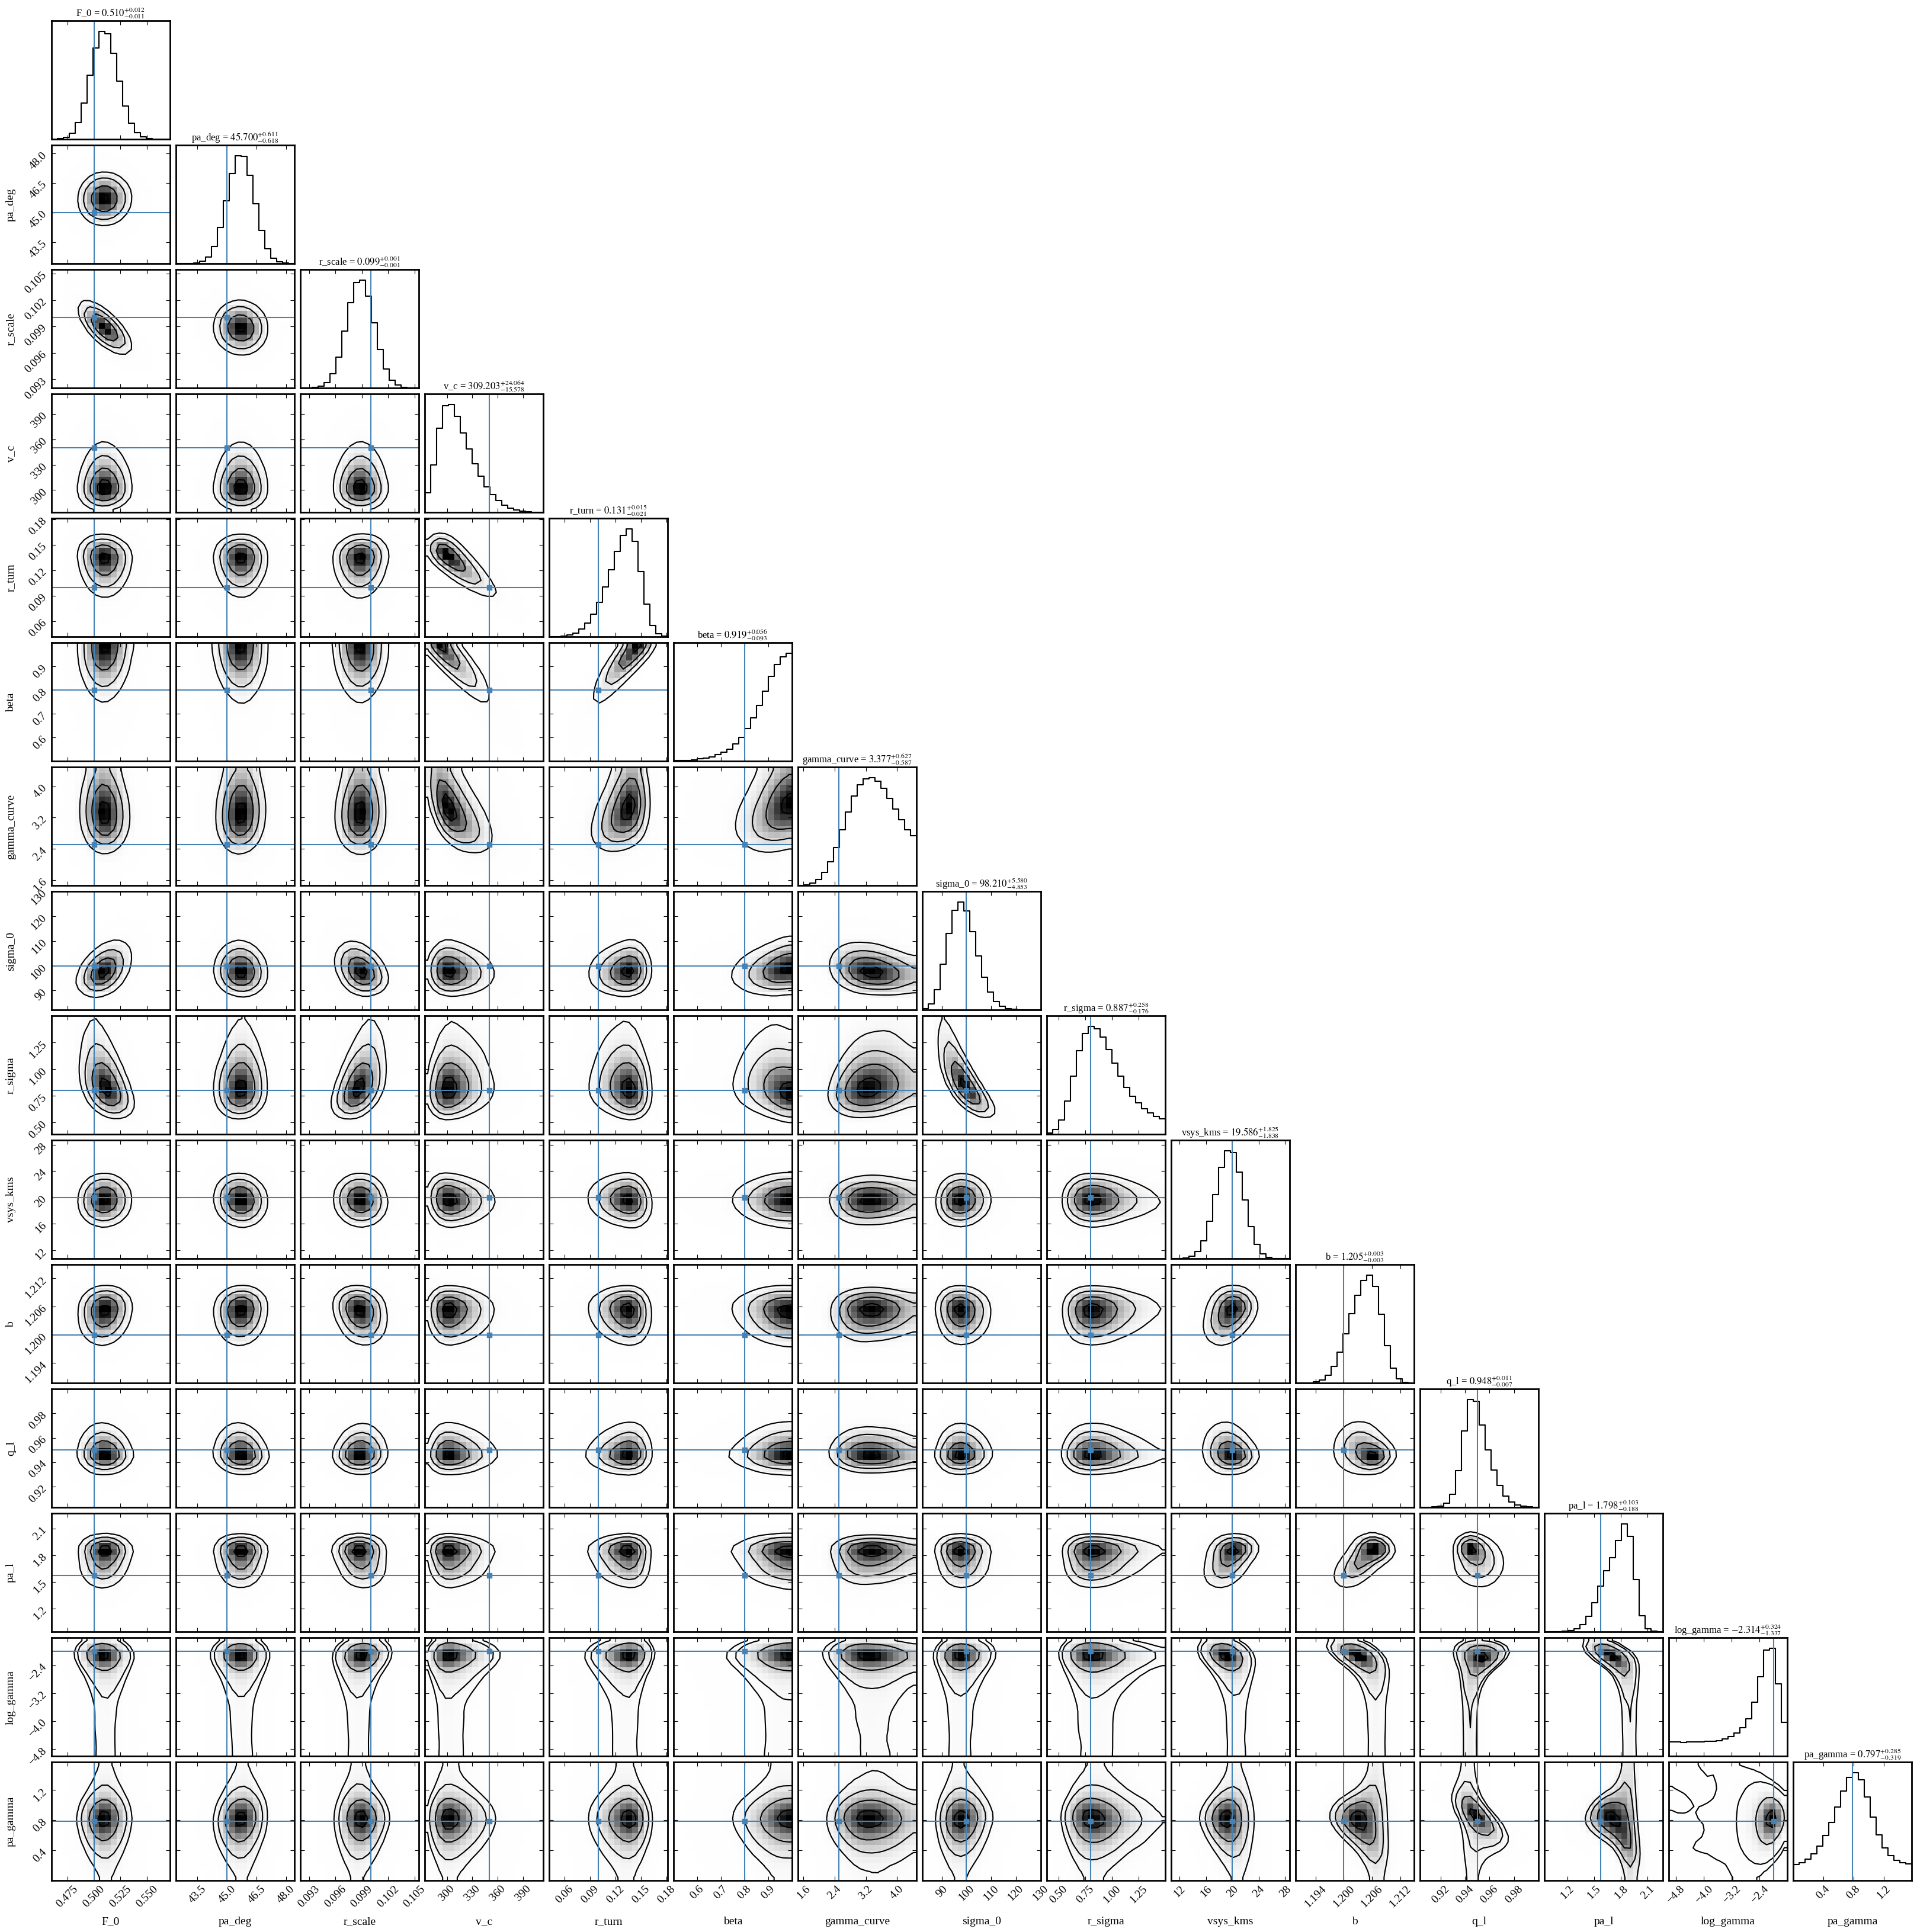


Saved corner plot: ./figure/corner_mock_lens_fix_vis.pdf

 Best-fit parameters vs Truth
F_0           best=    0.5142   truth=    0.5000   Δ=+0.0142
pa_deg        best=   45.9316   truth=   45.0000   Δ=+0.9316
r_scale       best=    0.0986   truth=    0.1000   Δ=-0.0014
v_c           best=  305.6872   truth=  350.0000   Δ=-44.3128
r_turn        best=    0.1372   truth=    0.1000   Δ=+0.0372
beta          best=    0.9508   truth=    0.8000   Δ=+0.1508
gamma_curve   best=    3.0174   truth=    2.5000   Δ=+0.5174
sigma_0       best=  101.9363   truth=  100.0000   Δ=+1.9363
r_sigma       best=    0.7773   truth=    0.8000   Δ=-0.0227
vsys_kms      best=   18.2970   truth=   20.0000   Δ=-1.7030
b             best=    1.2007   truth=    1.2000   Δ=+0.0007
q_l           best=    0.9451   truth=    0.9500   Δ=-0.0049
pa_l          best=    1.5381   truth=    1.5708   Δ=-0.0327
log_gamma     best=   -1.9197   truth=   -2.0000   Δ=+0.0803
pa_gamma      best=    0.9090   truth=    0.7854   Δ=+0.

In [28]:
import numpy as np
import corner

import matplotlib.pyplot as plt

# ===============================
# 1. Load saved chain
# ===============================

savename = f"./mcmc_chain_mock_cube_vis.npz"
npzfile = np.load(savename, allow_pickle=True)

chain = npzfile["chain"]              # shape: (nsteps, nwalkers, ndim)
logprob = npzfile["logprob"]          # shape: (nsteps, nwalkers)
param_names = list(npzfile["param_names"])

print("Loaded chain:")
print(" chain shape:", chain.shape)
print(" logprob shape:", logprob.shape)
print(" ndim:", len(param_names))


# ===============================
# 2. Truth parameters（mock_params）をここで明示的に入れる
# ===============================

print("\nTruth parameters loaded:")
for name, val in zip(param_names, mock_params):
    print(f" {name:12s} = {val:.4f}")


# ===============================
# 3. Flatten chain
# ===============================

nsteps, nwalkers, ndim = chain.shape
flat_chain = chain.reshape((-1, ndim))

print("\nFlattened chain shape:", flat_chain.shape)


# ===============================
# 4. Corner plot
# ===============================

fig = corner.corner(
    flat_chain,
    labels=param_names,
    truths=mock_params,
    show_titles=True,
    smooth=1.0,
    smooth1d=1.0,
    plot_density=True,
    plot_datapoints=False,
    title_fmt=".3f",
    title_kwargs={"fontsize": 12},
)

fig.savefig("./figure/corner_mock_lens_fix_vis.pdf", dpi=300, bbox_inches="tight", pad_inches=0.05)
plt.show()

print("\nSaved corner plot: ./figure/corner_mock_lens_fix_vis.pdf")

# ===============================
# 5. 真値 vs 最尤推定値
# ===============================

# 最も logprob が大きい点を best-fit とする
idx = np.unravel_index(np.argmax(logprob), logprob.shape)
best_theta = chain[idx[0], idx[1], :]

print("\n==============================")
print(" Best-fit parameters vs Truth")
print("==============================")

for name, best, truth in zip(param_names, best_theta, mock_params):
    print(f"{name:12s}  best={best:10.4f}   truth={truth:10.4f}   Δ={best-truth:+.4f}")

print("\nCompleted comparison.")

In [29]:
loglike(mock_params), loglike(best_theta)

(np.float64(-14343.300101190069), np.float64(-14336.78012561741))

In [30]:
print("img_ctx.x_s, y_s, inc_deg =", img_ctx.x_s, img_ctx.y_s, img_ctx.inc_deg)
print("mock truth               =", mock_x_s, mock_y_s, mock_inc_deg)

img_ctx.x_s, y_s, inc_deg = 0.03476715625595292 0.02914702617347071 31.97480712369869
mock truth               = 0.034 0.029 30.0


In [31]:
### rotation curve with error band ###
# サンプルから rotation curve を計算
from tqdm import tqdm
from glint.source import Vrot_Courteau1997
n_samples = flat_chain.shape[0]
radius_rc = np.arange(0, 0.8+1e-6, 0.01) # 0含める

# 5個おきのサンプルだけ使う
idx = np.arange(0, n_samples, 5)

vrot_samples = []
for i in tqdm(range(0, n_samples, 5)):
    params = flat_chain[i]
    v_c = params[3]
    # v_c = 350
    r_turn = params[4]
    beta_curve = params[5]
    gamma_curve = params[6]
    vrot_samples.append(Vrot_Courteau1997(r=radius_rc, v_c=v_c, r_turn=r_turn, gamma=gamma_curve, beta=beta_curve))
vrot_samples = np.array(vrot_samples)
vrot_median = np.median(vrot_samples, axis=0)
vrot_16 = np.percentile(vrot_samples, 16, axis=0)
vrot_84 = np.percentile(vrot_samples, 84, axis=0)   

100%|██████████| 600000/600000 [00:11<00:00, 51976.76it/s]


Saved to ./figure/rotation_curve_mock_lens_fix_vis.pdf


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1772913/564135901.py:3: SyntaxWarning: invalid escape sequence '\s'
  ax.fill_between(radius_rc, vrot_16, vrot_84, color='blue', alpha=0.3, label='1$\sigma$ uncertainty')


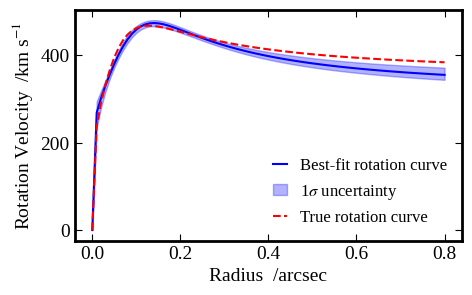

In [32]:
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(radius_rc, vrot_median, color='blue', label='Best-fit rotation curve')
ax.fill_between(radius_rc, vrot_16, vrot_84, color='blue', alpha=0.3, label='1$\sigma$ uncertainty')
ax.plot(radius_rc, Vrot_Courteau1997(r=radius_rc, v_c=mock_v_c, r_turn=mock_r_turn, gamma=mock_gamma_curve, beta=mock_beta_curve), color='red', linestyle='--', label='True rotation curve')
ax.set_xlabel('Radius  /arcsec', fontsize=14)
ax.set_ylabel(r'Rotation Velocity  /km s$^{-1}$', fontsize=14)
ax.legend(fontsize=12)
# ax.set_ylim(300, 600)
fig.savefig("./figure/rotation_curve_mock_lens_fix_vis.pdf", dpi=200, bbox_inches="tight", pad_inches=0.05)
print("Saved to ./figure/rotation_curve_mock_lens_fix_vis.pdf")
plt.show()

## Compare models and observations

In [33]:
h = fits.getheader("./sim_imaging/casa_clean.image.fits")
bmaj_as = h['BMAJ'] * 3600
bmin_as = h['BMIN'] * 3600
bpa_deg = h['BPA']
print(f"Beam size: {bmaj_as:.2f} x {bmin_as:.2f} arcsec, PA={bpa_deg:.1f} deg")

bmaj_pix = bmaj_as / pixsize_img
bmin_pix = bmin_as / pixsize_img
print(f"Beam size: {bmaj_pix:.2f} x {bmin_pix:.2f} pixels")

Beam size: 0.28 x 0.27 arcsec, PA=40.9 deg
Beam size: 13.96 x 13.41 pixels


Saved to ./figure/channel_maps_mock_lens_fix_vis.pdf


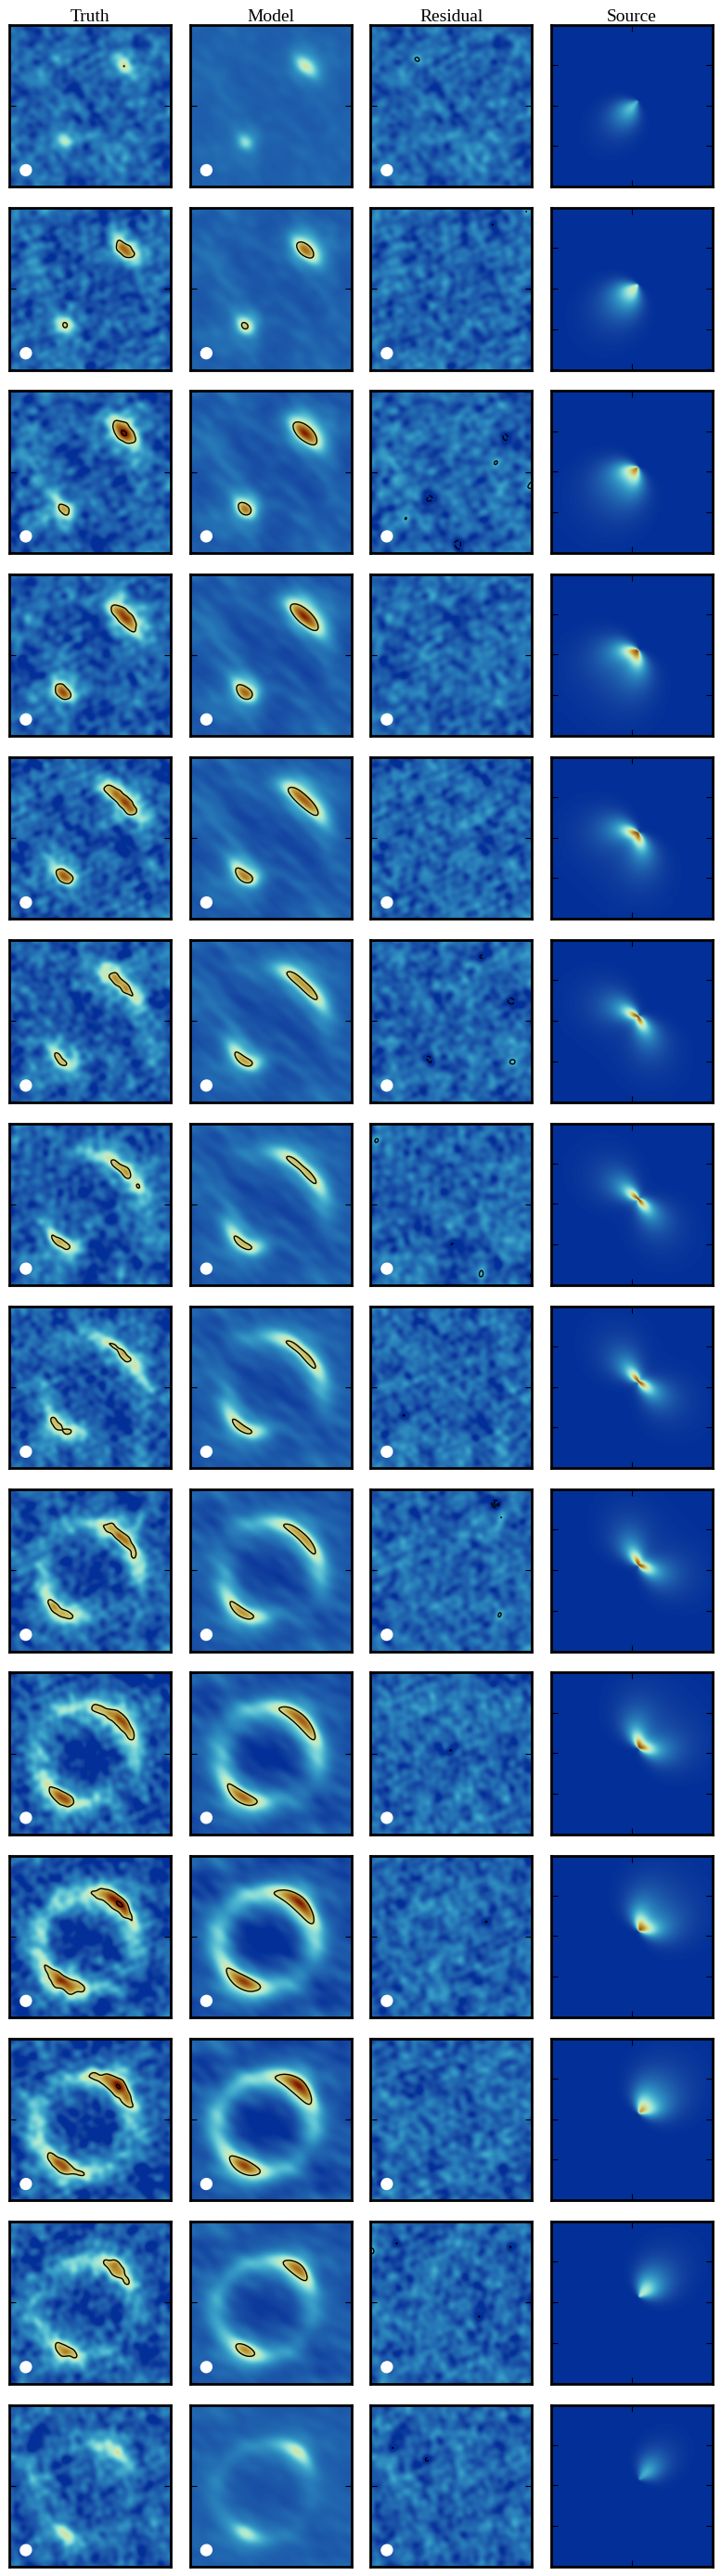

In [34]:
### 観測：observed visibilityをNUFFTしてdirty mapにしたもの
mock_dirty_cube = np.full((nchan, ny_img, nx_img), np.nan)
beam_3D = np.full((nchan, ny_img, nx_img), np.nan)
for i in range(nchan):
    mock_dirty, beam = vis_to_image_finufft_type3(
        u=u[~flag][slices[i]], v=v[~flag][slices[i]],
        V=vis[~flag][slices[i]],  # unflagged dataだけ使う
        V_weight=np.ones_like(vis[~flag][slices[i]]),  # 重みは1でいい
        xx_as=xx_img, yy_as=yy_img,
        eps=1e-6
    )
    mock_dirty_cube[i] = mock_dirty
    beam_3D[i] = beam

### モデル：best_thetaをforward_model_3D_visに入れて、model visibilityを作り、さらにそれをNUFFTしてmodel dirty mapにする
best_theta = chain[np.unravel_index(np.argmax(logprob), logprob.shape)]
best_model_vis = forward_model_3D_vis(best_theta, img_ctx, uv_ctx)
best_model_vis = forward_model_3D_vis(mock_params, img_ctx, uv_ctx)

best_model_dirty_cube = np.full((nchan, ny_img, nx_img), np.nan)
for i in range(nchan):
    best_model_dirty, _ = vis_to_image_finufft_type3(
        u=u[~flag][slices[i]], v=v[~flag][slices[i]],
        V=best_model_vis[slices[i]],
        V_weight=np.ones_like(best_model_vis[slices[i]]),
        xx_as=xx_img,
        yy_as=yy_img,
        eps=1e-6
    )
    best_model_dirty_cube[i] = best_model_dirty

### Source
best_source, _, _ = forward_model_3D_image(best_theta, img_ctx)

# Plot cube for each channel
# Some settings for plotting
vmax = np.nanmax(mock_dirty_cube) * 0.9
width = 2
titles = ["Truth", "Model", "Residual", "Source"]

from astropy.stats import sigma_clipped_stats, mad_std
rms1 = mad_std(mock_dirty_cube[0], ignore_nan=True)
rms2 = mad_std(mock_dirty_cube[-1], ignore_nan=True)
rms = (rms1 + rms2) / 2

fig, axes = plt.subplots(nchan, ncols=4, figsize=(width*4, width*nchan))
fig.subplots_adjust(wspace=0., hspace=0.0)
for i in range(nchan):
    im0 = axes[i, 0].imshow(mock_dirty_cube[i], cmap=cm.roma_r, origin="lower", vmin=-2*rms, vmax=vmax)
    axes[i, 0].contour(mock_dirty_cube[i]/rms, levels=[8,16,32], colors='black', linewidths=1.0)
    im1 = axes[i, 1].imshow(best_model_dirty_cube[i], cmap=cm.roma_r, origin="lower", vmin=-2*rms, vmax=vmax)
    axes[i, 1].contour(best_model_dirty_cube[i]/rms, levels=[8,16,32], colors='black', linewidths=1.0)
    # im2 = axes[i, 2].imshow((mock_dirty_cube[i] - best_model_dirty_cube[i]) / rms, cmap=cm.roma_r, origin="lower", vmin=-3, vmax=3)
    im2 = axes[i, 2].imshow((mock_dirty_cube[i] - best_model_dirty_cube[i]), cmap=cm.roma_r, origin="lower", vmin=-2*rms, vmax=vmax)
    axes[i, 2].contour((mock_dirty_cube[i] - best_model_dirty_cube[i]) / rms, levels=[-5,-4,-3,3,4,5], colors='black', linewidths=1.0)
    im3 = axes[i, 3].imshow(best_source[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=np.nanmax(best_source))

    if i==0:
        for j in range(4):
            axes[i, j].set_title(titles[j], fontsize=14, pad=-2)
    for j in range(4):
        # divider = make_axes_locatable(axes[i,j])
        # cax = divider.append_axes("right", size="5%", pad=0.)
        # fig.colorbar([im0, im1, im2, im3][j], cax=cax)
        axes[i, j].set_xticklabels([])
        axes[i, j].set_yticklabels([])

    
    # beam ellipseを画像の左下10%の位置に追加
    from matplotlib.patches import Ellipse
    for j in range(3):  # 最初の3列にbeam ellipseを追加
        beam_ellipse = Ellipse(
            xy=(nx_img*0.1, ny_img*0.1),  # 画像の左下10%の位置
            width=bmaj_pix,
            height=bmin_pix,
            angle=bpa_deg,
            edgecolor='white',
            facecolor='white',
            linewidth=1.0
        )
        axes[i, j].add_patch(beam_ellipse)



fig.savefig("./figure/channel_maps_mock_lens_fix_vis.pdf", dpi=200, bbox_inches="tight", pad_inches=0.05)
print("Saved to ./figure/channel_maps_mock_lens_fix_vis.pdf")
plt.tight_layout()

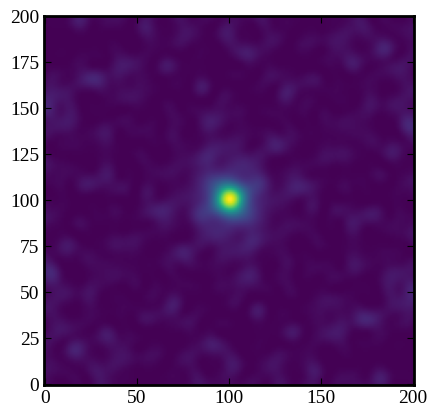

In [35]:
plt.imshow(beam_3D[0], origin="lower")

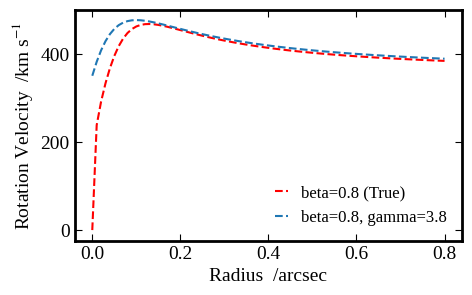

In [36]:
from glint.source import Vrot_Courteau1997
radius_rc = np.arange(0, 0.8+1e-6, 0.01) # 0含める
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(radius_rc, Vrot_Courteau1997(r=radius_rc, v_c=mock_v_c, r_turn=mock_r_turn, gamma=mock_gamma_curve, beta=0.8), color='red', linestyle='--', label='beta=0.8 (True)')
ax.plot(radius_rc, Vrot_Courteau1997(r=radius_rc, v_c=mock_v_c, r_turn=mock_r_turn, gamma=1.8, beta=1), linestyle='--', label='beta=0.8, gamma=3.8')
# ax.plot(radius_rc, Vrot_Courteau1997(r=radius_rc, v_c=mock_v_c, r_turn=mock_r_turn, gamma=mock_gamma_curve, beta=0.5),  linestyle='--', label='beta=0.5')
# ax.plot(radius_rc, Vrot_Courteau1997(r=radius_rc, v_c=mock_v_c, r_turn=mock_r_turn, gamma=mock_gamma_curve, beta=0.7),  linestyle='--', label='beta=0.7')
ax.set_xlabel('Radius  /arcsec', fontsize=14)
ax.set_ylabel(r'Rotation Velocity  /km s$^{-1}$', fontsize=14)
ax.legend(fontsize=12)
# ax.set_ylim(300, 600)
plt.show()